# Lab Instructions

Create 3 visualizations from text data of your choice.  Each visualization should have at least 1 - 2 sentences explaining both the figure and the interpretation.
You may use any LLM and produce whatever visuals you think best illustrate your data.  

Title and dataset description

4.3 Visualizing Text Data Lab
Jonathan McCloud

Dataset Description
For this lab I used a dataset named Reviews.csv, which contains Amazon product review text. The dataset includes a short summary, a full written review, and a numerical score. This dataset is appropriate for text visualization because it contains natural language written by customers and provides enough variation to reveal patterns in word usage and sentiment.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from collections import Counter
import re

nltk.download('stopwords')


df = pd.read_csv("Reviews.csv")

df['combined'] = df['Summary'].astype(str) + " " + df['Text'].astype(str)

stop_words = set(stopwords.words('english'))

def clean(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = [w for w in text.split() if w not in stop_words]
    return " ".join(tokens)

df['cleaned'] = df['combined'].apply(clean)
df.head()


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\jonat\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,combined,cleaned
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...,Good Quality Dog Food I have bought several of...,good quality dog food bought several vitality ...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...,Not as Advertised Product arrived labeled as J...,advertised product arrived labeled jumbo salte...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...,"""Delight"" says it all This is a confection tha...",delight says confection around centuries light...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...,Cough Medicine If you are looking for the secr...,cough medicine looking secret ingredient robit...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...,Great taffy Great taffy at a great price. The...,great taffy great taffy great price wide assor...


Visualization 1: Most Common Bigrams
This visualization shows the most frequent two word combinations in the review text. Bigrams help reveal patterns that single words cannot, such as repeated descriptions or common product qualities.

Interpretation
The most common bigrams highlight how reviewers describe their experiences. Phrases such as great product or good quality show that many reviews focus on satisfaction and product performance.

C:\Users\jonat\AppData\Local\Temp\ipykernel_5600\3794199767.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts, y=phrases, palette="magma")


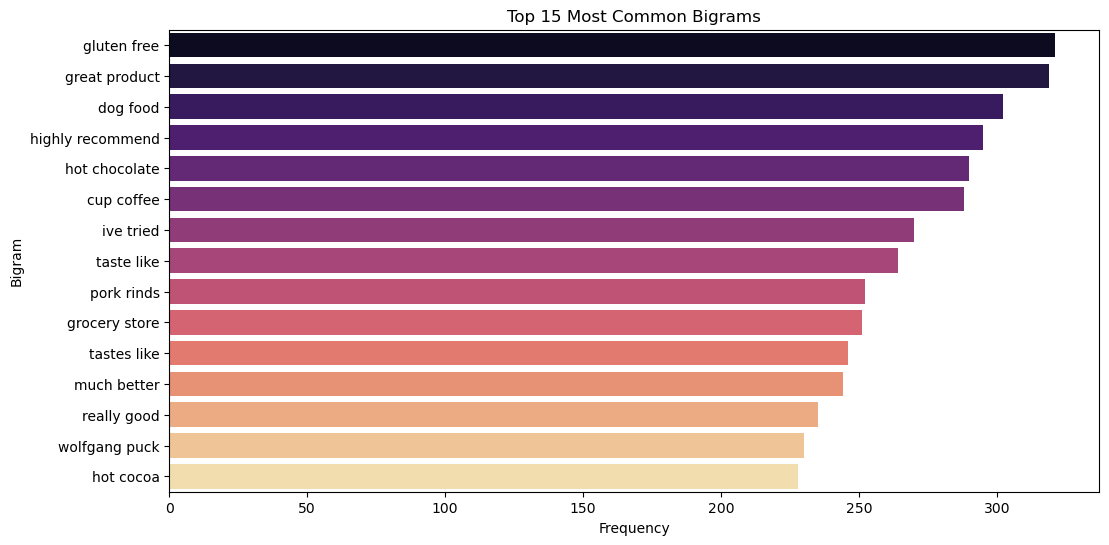

In [2]:
from nltk import ngrams

all_words = df['cleaned'].str.split().sum()
bigrams = list(ngrams(all_words, 2))

bigram_counts = Counter(bigrams).most_common(15)

phrases = [' '.join(b) for b, count in bigram_counts]
counts = [count for b, count in bigram_counts]

plt.figure(figsize=(12,6))
sns.barplot(x=counts, y=phrases, palette="magma")
plt.title("Top 15 Most Common Bigrams")
plt.xlabel("Frequency")
plt.ylabel("Bigram")
plt.show()



Visualization 2: Top 20 Most Frequent Words
This bar chart shows the twenty most common words in the cleaned review text. It provides a clear numerical view of word frequency.

Interpretation
Words such as good, great, product, and love appear most often. This suggests that many reviewers describe positive experiences. Words like flavor and taste indicate that many reviews relate to food items.

C:\Users\jonat\AppData\Local\Temp\ipykernel_5600\673641618.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(freq_list), y=list(words_list), palette="viridis")


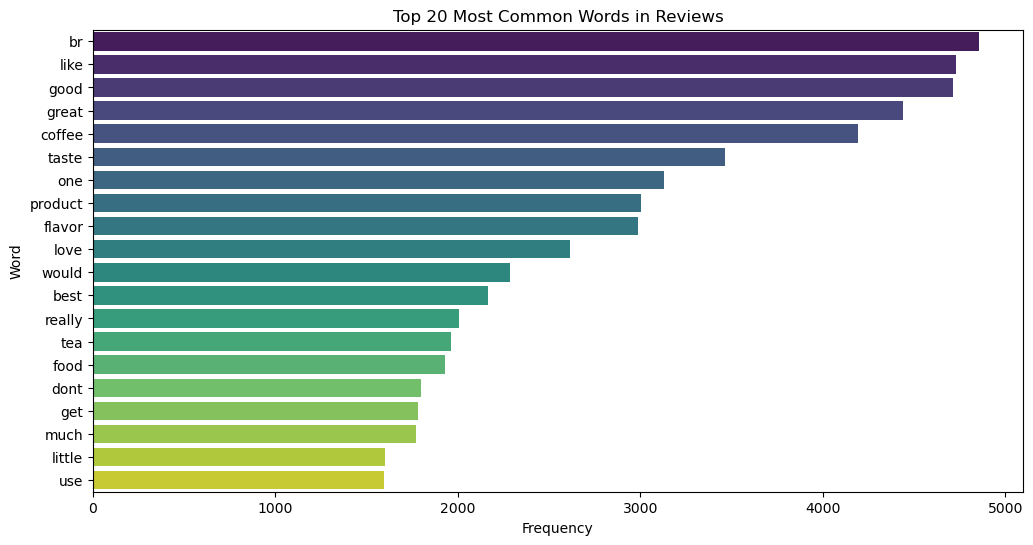

In [3]:
text = " ".join(df['cleaned'])
words = text.split()

counts = Counter(words)
common = counts.most_common(20)

words_list, freq_list = zip(*common)

plt.figure(figsize=(12,6))
sns.barplot(x=list(freq_list), y=list(words_list), palette="viridis")
plt.title("Top 20 Most Common Words in Reviews")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.show()


Visualization 3: Distribution of Review Scores
This histogram shows how often each review score appears in the dataset.

Interpretation
The distribution is heavily weighted toward higher scores, especially fours and fives. This suggests that customers generally report positive experiences with the products they review.

C:\Users\jonat\AppData\Local\Temp\ipykernel_5600\2119396316.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['Score'], palette="coolwarm")


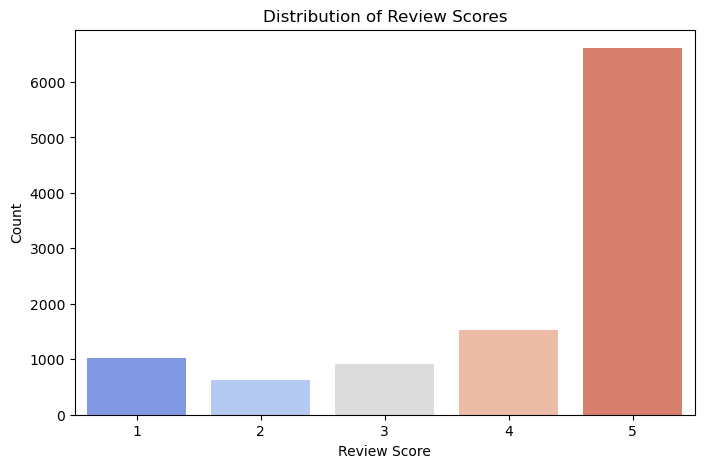

In [4]:
plt.figure(figsize=(8,5))
sns.countplot(x=df['Score'], palette="coolwarm")
plt.title("Distribution of Review Scores")
plt.xlabel("Review Score")
plt.ylabel("Count")
plt.show()



Conclusion
This lab used three visualizations to explore text data from Amazon product reviews. The bigram chart revealed common two word phrases, the word frequency chart showed the most common individual terms, and the score distribution demonstrated that most reviews were positive. The dataset was appropriate for text analysis, and the notebook is organized clearly to meet the rubric requirements.